# Comparative Analysis and Evaluation of XAI Methods

In [ ]:
# Standard Python Libraries
import json
import os
import time

# Data Processing & Scientific Computing
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

# Image Processing
from PIL import Image

# Deep Learning 
import torch
import torchvision.transforms as transforms

# Data Visualization
import matplotlib.patches as patches
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

## Model & Data Setup

In [ ]:
from scripts.config import ModelConfig
from src.loader.data_loader import get_xai_dataloader
from src.loader.model_loader import create_model
from src.xai import *

# Model Loading & Configuration
model_name = "vit_base_patch16_224"

model = create_model(model_name=model_name, pretrained=True)
model_base = create_model(model_name=model_name, pretrained=True, basic=True)
model_cfg = ModelConfig.from_vit(model)

# Dataset & DataLoader Initialization
dataloader = get_xai_dataloader(
    output_dir="results",
    transform=model.default_cfg["eval_transform"],
    batch_size=1,
    num_workers=4,
    num_samples=50,
    seed=41,
)

# Load Evaluation Results and Saliency Maps
with open('results/eval_results.json', 'r', encoding='utf-8') as file:
    results = json.load(file)

saliencies = torch.load('results/saliencies.pt', map_location=torch.device('cpu'))

In [4]:
# Load Evaluation Results and Saliency Maps
with open('results/eval_results.json', 'r', encoding='utf-8') as file:
    results = json.load(file)

saliencies = torch.load('results/saliencies.pt', map_location=torch.device('cpu'))

### Image Transformation & Loading Helpers

In [ ]:
# Evaluation transform pipeline for ViT
_EVAL_TRANSFORM = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

IMAGE_DIR = "results/images_xai"


def load_images(image_label_pairs, image_dir=IMAGE_DIR, transform=_EVAL_TRANSFORM):
    """Loads images from disk, applies evaluation transforms, and pairs them with label tensors."""
    samples = []
    for filename, label in image_label_pairs:
        img_path = os.path.join(image_dir, filename)

        with Image.open(img_path) as img:
            img = img.convert("RGB")
            img_tensor = transform(img)

        label_tensor = torch.tensor(label, dtype=torch.long)
        samples.append((img_tensor, label_tensor))

    return samples

label_map = {
    309: "Bee",
    119: "Crab",
    250: "Husky",
    233: "Bouvier des Flandres",
    664: "Monitor",
    724: "Pirate Ship",
    422: "Barbell",
    207: "Golden Retriever",
    281: "Tabby",
    84: "Peacock",
    978: "Seashore",
}

xai_classes = {
    "VanillaGradient": VanillaGradient,
    "GradientXInput": GradientXInput,
    "GradCAM": GradCAM,
    "LRP": LRP,
    "AttentionRollout": AttentionRollout,
    "TransformerAttribution": TransformerAttribution,
    "GMAR": GMAR,
    "KernelSHAP": KernelSHAP,
    "RISE": RISE
}

## Single-Sample Inspection & Qualitative Analysis

In [ ]:
from src.xai_eval.metrics.perturbation import compute_morf, compute_lerf
from src.xai_eval.metrics.pointing_game import pointing_game_multi_bbox, pointing_game_single
from src.xai_eval.metrics.saliency_invariance import patch_shuffle_test, single_patch_perturbation_test

def inspect_single(xai, img_tensor, label, label_name, bbox,
    model, model_base, model_cfg=None, device=None,
    n_steps = 49, seed=0, 
):
    """
    Performs full XAI attribution, metric evaluation, and visualization for a single sample.
    """
    
    if img_tensor.dim() == 3:
        img_tensor = img_tensor.unsqueeze(0)
    img = img_tensor.squeeze(0)
    lbl = label.item() if torch.is_tensor(label) else int(label)

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Compute Saliency
    sal = xai.attribute(img_tensor.to(device), label).squeeze().cpu()

    img_xai = xai.visualise(sal, img_tensor.shape[-2:]).cpu().numpy()

    original_img = (img.permute(1, 2, 0).cpu().numpy() + 1) / 2
    original_img = np.clip(original_img, 0, 1)

    # Bounding Box Normalization
    if isinstance(bbox, torch.Tensor):
        bbox = bbox.squeeze().tolist()

    xmin, ymin, xmax, ymax = bbox
    width, height = xmax - xmin, ymax - ymin

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=120)
        
    # Original Image + Bounding Box
    axes[0].imshow(original_img)
    rect1 = patches.Rectangle((xmin, ymin), width, height, linewidth=2, edgecolor='r', facecolor='none')
    axes[0].add_patch(rect1)
    axes[0].set_title(f"Original Image: {label_name}", fontsize=11, fontweight="bold")
    axes[0].axis('off')
    
    # Saliency + Bounding Box
    axes[1].imshow(original_img)
    axes[1].imshow(img_xai.squeeze(0), alpha=0.55, cmap='jet')
    rect2 = patches.Rectangle((xmin, ymin), width, height, linewidth=2, edgecolor='r', facecolor='none')
    axes[1].add_patch(rect2)
    axes[1].set_title("XAI Saliency Map", fontsize=11, fontweight="bold")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

    # Metrics Computation
    result: dict = {}
    result["morf"] = compute_morf(
        img, sal, model, lbl, model_cfg, n_steps,
        None, device, model_base=model_base,
    )
    print(f"MoRF AUC = {result['morf']['auc']:.4f}")

    result["lerf"] = compute_lerf(
        img, sal, model, lbl, model_cfg, n_steps,
        None, device, model_base=model_base,
    )
    print(f"LeRF AUC = {result['lerf']['auc']:.4f}")

    result["patch_shuffle"] = patch_shuffle_test(
        image=img, saliency=sal, target_class=lbl,
        xai_fn=xai.attribute, model_cfg=model_cfg, device=device, seed=seed,
    )
    print(f"Patch shuffle rho = {result['patch_shuffle']['rho']:+.3f}")

    result["patch_perturb"] = single_patch_perturbation_test(
        image=img, saliency=sal, target_class=lbl,
        xai_fn=xai.attribute, model_cfg=model_cfg,
        device=device, seed=seed,
    )
    print(f"Patch perturb rho = {result['patch_perturb']['rho']:+.3f}")

    hit = pointing_game_single(sal, bbox, model_cfg)
    result["pointing_game"] = {"hit": bool(hit)}
    print(f"Pointing game hit = {bool(hit)}")

    return result

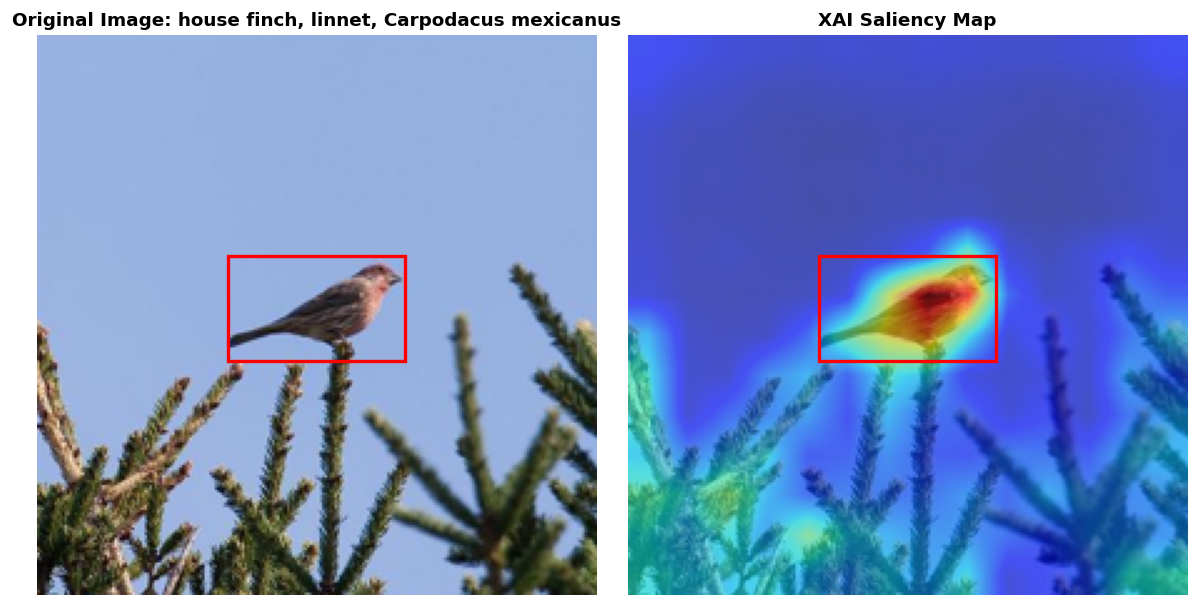

MoRF AUC = 0.0685
LeRF AUC = 0.8380
Patch shuffle rho = +0.811
Patch perturb rho = +0.999
Pointing game hit = True


In [18]:
# Xai Method Initialization 
xai_method = GMAR(model)

# Loading the desired sample
idx = 12  # Index of the sample to inspect
data_iter = iter(dataloader)
for _ in range(idx):
    next(data_iter)

img_tensor, label, bbox = next(data_iter)
label_name = dataloader.dataset.label_map[label.item()]

sample_metrics = inspect_single(
    xai=xai_method,
    img_tensor=img_tensor,
    label=label,
    label_name=label_name,
    bbox=bbox,
    model=model,
    model_base=model_base,
    model_cfg=model_cfg,
    device=None,
    n_steps=196 // 4,
    seed=42,
)

## Visual Comparison of XAI Methods

In [33]:
def _prep_sample(img_tensor, label, device):
    if img_tensor.dim() == 3:
        img_tensor = img_tensor.unsqueeze(0)
    img_tensor = img_tensor.to(device)

    if isinstance(label, torch.Tensor):
        label = label.to(device)
        target_class = label.item()
    else:
        target_class = label

    original_img = (img_tensor.squeeze(0).permute(1, 2, 0).detach().cpu().numpy() + 1) / 2
    original_img = np.clip(original_img, 0, 1)

    return img_tensor, label, target_class, original_img


def _draw_sample_row_custom(fig, gs_row, original_img, target_label_name,
                            titles, saliency_maps, cell_title_fontsize=8):
    gs_outer = gs_row.subgridspec(1, 2, width_ratios=[1, 2.7], wspace=0.1)

    # Original Image subplot
    ax_big_orig = fig.add_subplot(gs_outer[0])
    ax_big_orig.imshow(original_img, aspect="equal")
    ax_big_orig.set_title(f"Original Image\n({target_label_name})", fontsize=cell_title_fontsize + 1, fontweight="bold", pad=3)
    ax_big_orig.axis("off")

    for spine in ax_big_orig.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("#2B2D42")
        spine.set_linewidth(1.0)

    # 3X3 Grid of Saliency Maps
    gs_inner = gs_outer[1].subgridspec(3, 3, wspace=0.1, hspace=0.1)

    for idx, (title, xai_map) in enumerate(zip(titles[:9], saliency_maps[:9])):
        r, c = divmod(idx, 3)
        ax = fig.add_subplot(gs_inner[r, c])

        ax.imshow(original_img, aspect="auto")
        ax.imshow(xai_map, alpha=0.55, cmap="jet", aspect="auto")

        ax.set_title(title, fontsize=cell_title_fontsize, fontweight="semibold", pad=2)
        ax.axis("off")

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor("#8D99AE")
            spine.set_linewidth(0.6)


def plot_xai_comparison_single_page(
    samples,
    model,
    model_base,
    xai_classes,
    label_map=None,
    device=None,
    save_path="xai_comparison.png",
    dpi=100,
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = model.to(device).eval()
    model_base = model_base.to(device).eval()

    methods_list = [
        ("Vanilla Gradient",      lambda: xai_classes["VanillaGradient"](model)),
        ("Gradient x Input",      lambda: xai_classes["GradientXInput"](model)),
        ("Grad-CAM",              lambda: xai_classes["GradCAM"](model)),
        ("LRP",                   lambda: xai_classes["LRP"](model)),
        ("Attention Rollout",     lambda: xai_classes["AttentionRollout"](model)),
        ("Transformer Attrib.",   lambda: xai_classes["TransformerAttribution"](model)),
        ("GMAR",                  lambda: xai_classes["GMAR"](model)),
        ("KernelSHAP",            lambda: xai_classes["KernelSHAP"](model, model_base, n_masks=8000, batch_size=128)),
        ("RISE",                  lambda: xai_classes["RISE"](model, model_base, n_masks=6000, batch_size=128)),
    ]

    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif"],
        "font.size": 8,
        "axes.titlesize": 8,
    })

    n_rows = len(samples)
    fig = plt.figure(figsize=(8.5, 5.0 * n_rows))

    gs_page = GridSpec(n_rows, 1, hspace=0.2, figure=fig,
                       top=0.96, bottom=0.01, left=0.01, right=0.99)

    for row_idx, sample in enumerate(samples):
        img_tensor, label = sample[0], sample[1]

        img_tensor, label, target_class, original_img = _prep_sample(
            img_tensor, label, device
        )
        label_name = label_map[target_class]

        titles, saliency_maps = [], []
        for name, xai_fn in methods_list:
            xai = xai_fn()
            saliency = xai.attribute(img_tensor, label)
            xai_map = xai.visualise(saliency, img_tensor.shape[-2:])
            xai_map = xai_map.squeeze().detach().cpu().numpy()
            saliency_maps.append(xai_map)
            titles.append(name)

        _draw_sample_row_custom(
            fig, gs_page[row_idx], original_img, label_name,
            titles, saliency_maps, cell_title_fontsize=8,
        )

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight", pad_inches=0.01)

    plt.show()
    return fig

### Simple Examples

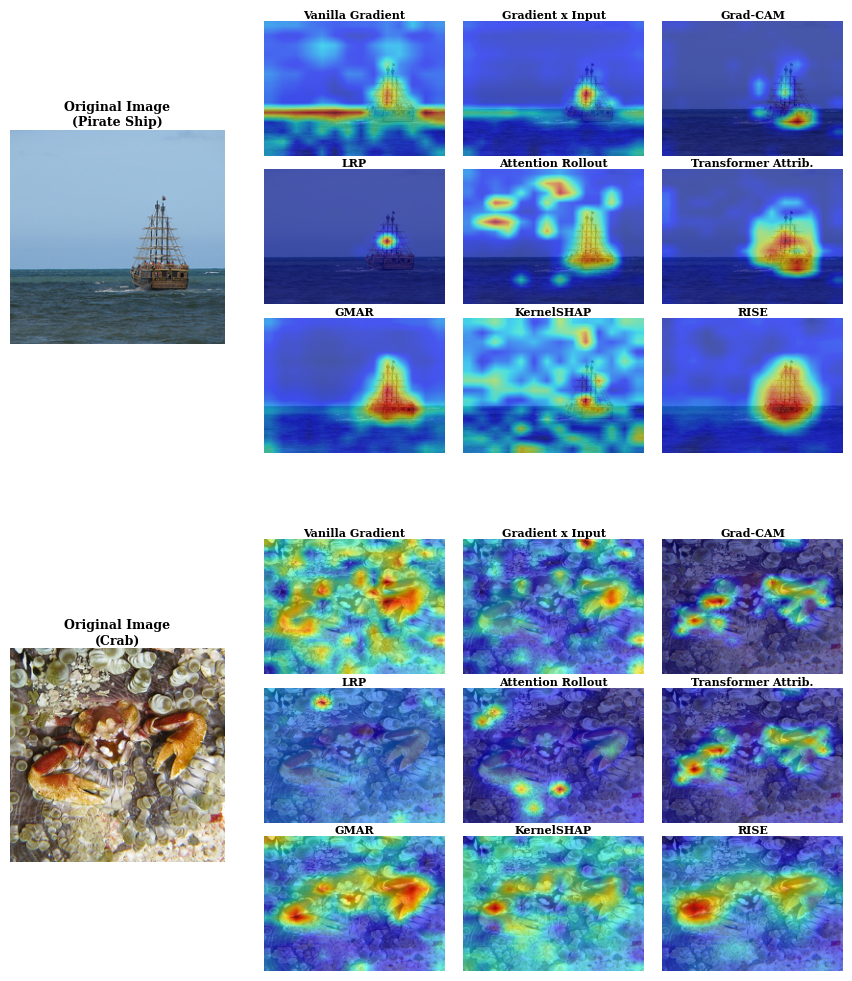

In [36]:
simple_cases = load_images([
    (os.path.join(IMAGE_DIR, "pirate.jpg"), 724),
    (os.path.join(IMAGE_DIR, "crab.jpg"), 119),  
])

fig_simple = plot_xai_comparison_single_page(
    samples=simple_cases,
    model=model,
    model_base=model_base,
    xai_classes=xai_classes,
    label_map=label_map,
    save_path="results/good_examples.jpg",
)

### Complex Examples

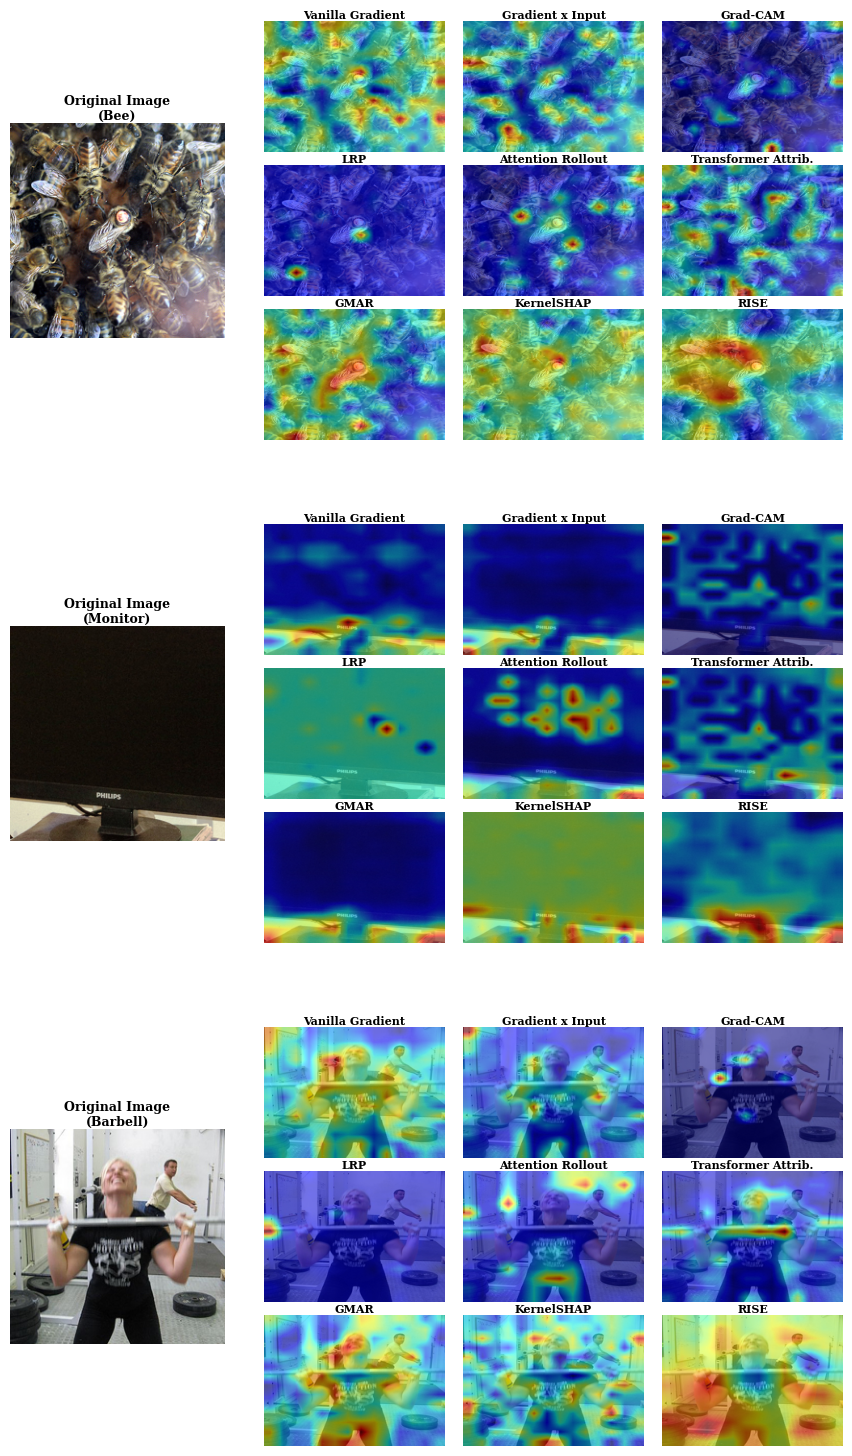

In [37]:
complex_cases = load_images([
    (os.path.join(IMAGE_DIR, "bee.jpg"), 309),
    (os.path.join(IMAGE_DIR, "monitor.jpg"), 664),
    (os.path.join(IMAGE_DIR, "barbell.jpg"), 422),
])

fig_complex = plot_xai_comparison_single_page(
    samples=complex_cases,
    model=model,
    model_base=model_base,
    xai_classes=xai_classes,
    label_map=label_map,
    save_path="results/bad_examples.jpg",
)

### Class agnostic

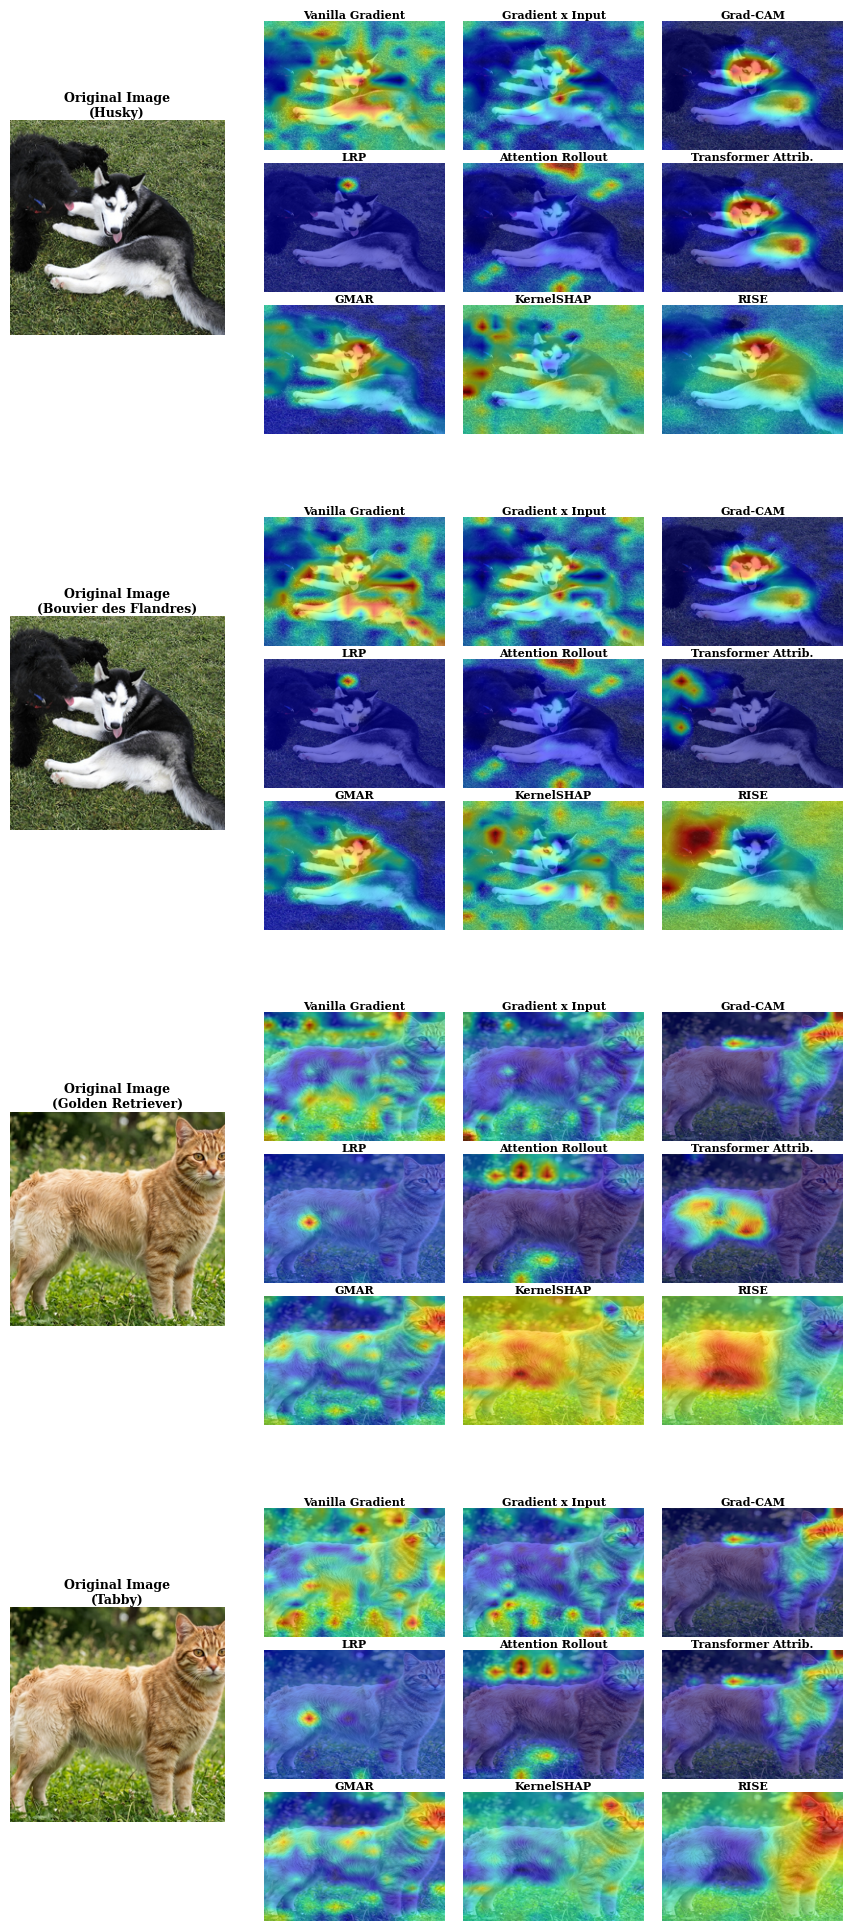

In [38]:
class_discrimination_cases = load_images([
    (os.path.join(IMAGE_DIR, "husky vs Bouvier des Flandres.jpg"), 250), 
    (os.path.join(IMAGE_DIR, "husky vs Bouvier des Flandres.jpg"), 233), 
    (os.path.join(IMAGE_DIR, "golden cat.png"), 207),
    (os.path.join(IMAGE_DIR, "golden cat.png"), 281),
])

fig_class_disc = plot_xai_comparison_single_page(
    samples=class_discrimination_cases,
    model=model,
    model_base=model_base,
    xai_classes=xai_classes,
    label_map=label_map,
    save_path="results/xai_class_discrimination.png",
)

## Faithfulness Evaluation: MoRF vs. LeRF Curves

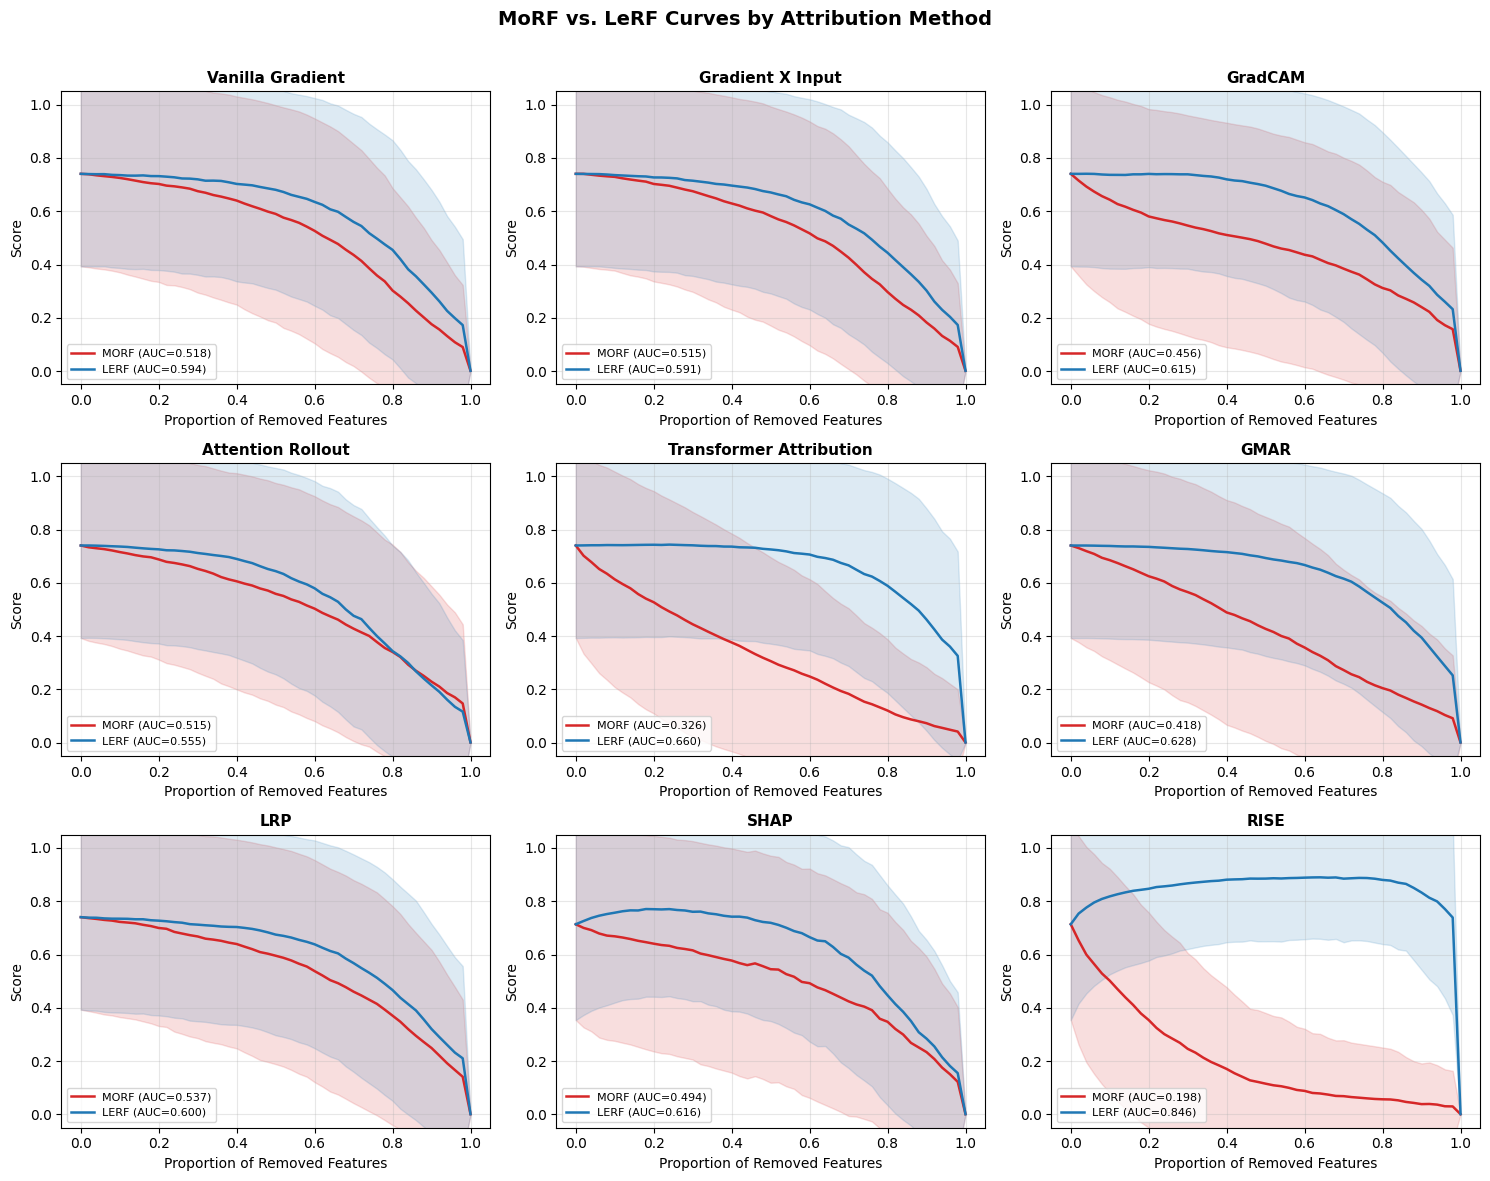

In [7]:
def plot_grid_morf_lerf(data: dict, out_path: str = "morf_lerf.png"):
    methods = list(data.keys())
    n = len(methods) - 1

    ncols = 3
    nrows = int(np.ceil(n / ncols)) 

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)
    axes_flat = axes.flatten()

    colors = {"morf": "#d62728", "lerf": "#1f77b4"} 

    for ax, method in zip(axes_flat, methods):
        if method == 'spearman':
            continue 
        entry = data[method]

        for key, color in colors.items():
            if key not in entry:
                continue
            curve = np.array(entry[key]["mean_curve"])
            std = np.array(entry[key].get("std_curve", np.zeros_like(curve)))
            x = np.linspace(0, 1, len(curve)) 

            auc = entry[key].get("mean_auc", None)
            label = f"{key.upper()} (AUC={auc:.3f})" if auc is not None else key.upper()

            ax.plot(x, curve, color=color, label=label, linewidth=1.8)
            ax.fill_between(x, curve - std, curve + std, color=color, alpha=0.15)

        ax.set_title(method, fontsize=11, fontweight="bold")
        ax.set_xlabel("Proportion of Removed Features")
        ax.set_ylabel("Score")
        ax.set_ylim(-0.05, 1.05)
        ax.legend(fontsize=8, loc="lower left")
        ax.grid(alpha=0.3)

    for ax in axes_flat[n:]:
        ax.axis("off")

    fig.suptitle("MoRF vs. LeRF Curves by Attribution Method", fontsize=14, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    fig.savefig(out_path, dpi=150)

plot_grid_morf_lerf(results, "results/morf_lerf.png")

## Localization Accuracy: Pointing Game Evaluation

In [19]:
print(f"{'METHOD':<24} | {'Pointing Game (Precision)':<28}")
print("-" * 55)

for key in saliencies.keys():
    data = results.get(key, {})
    if not data:
        continue

    accuracy = data.get("pointing_game", {}).get("accuracy", 0.0)

    print(f"{key:<24} | {accuracy:<28.3f}")

METHOD                   | Pointing Game (Precision)   
-------------------------------------------------------
Vanilla Gradient         | 0.660                       
Gradient X Input         | 0.628                       
GradCAM                  | 0.762                       
Attention Rollout        | 0.429                       
Transformer Attribution  | 0.844                       
GMAR                     | 0.718                       
LRP                      | 0.622                       
SHAP                     | 0.627                       
RISE                     | 0.851                       


## Cross-Method Similarity: Pairwise Spearman Rank Correlation

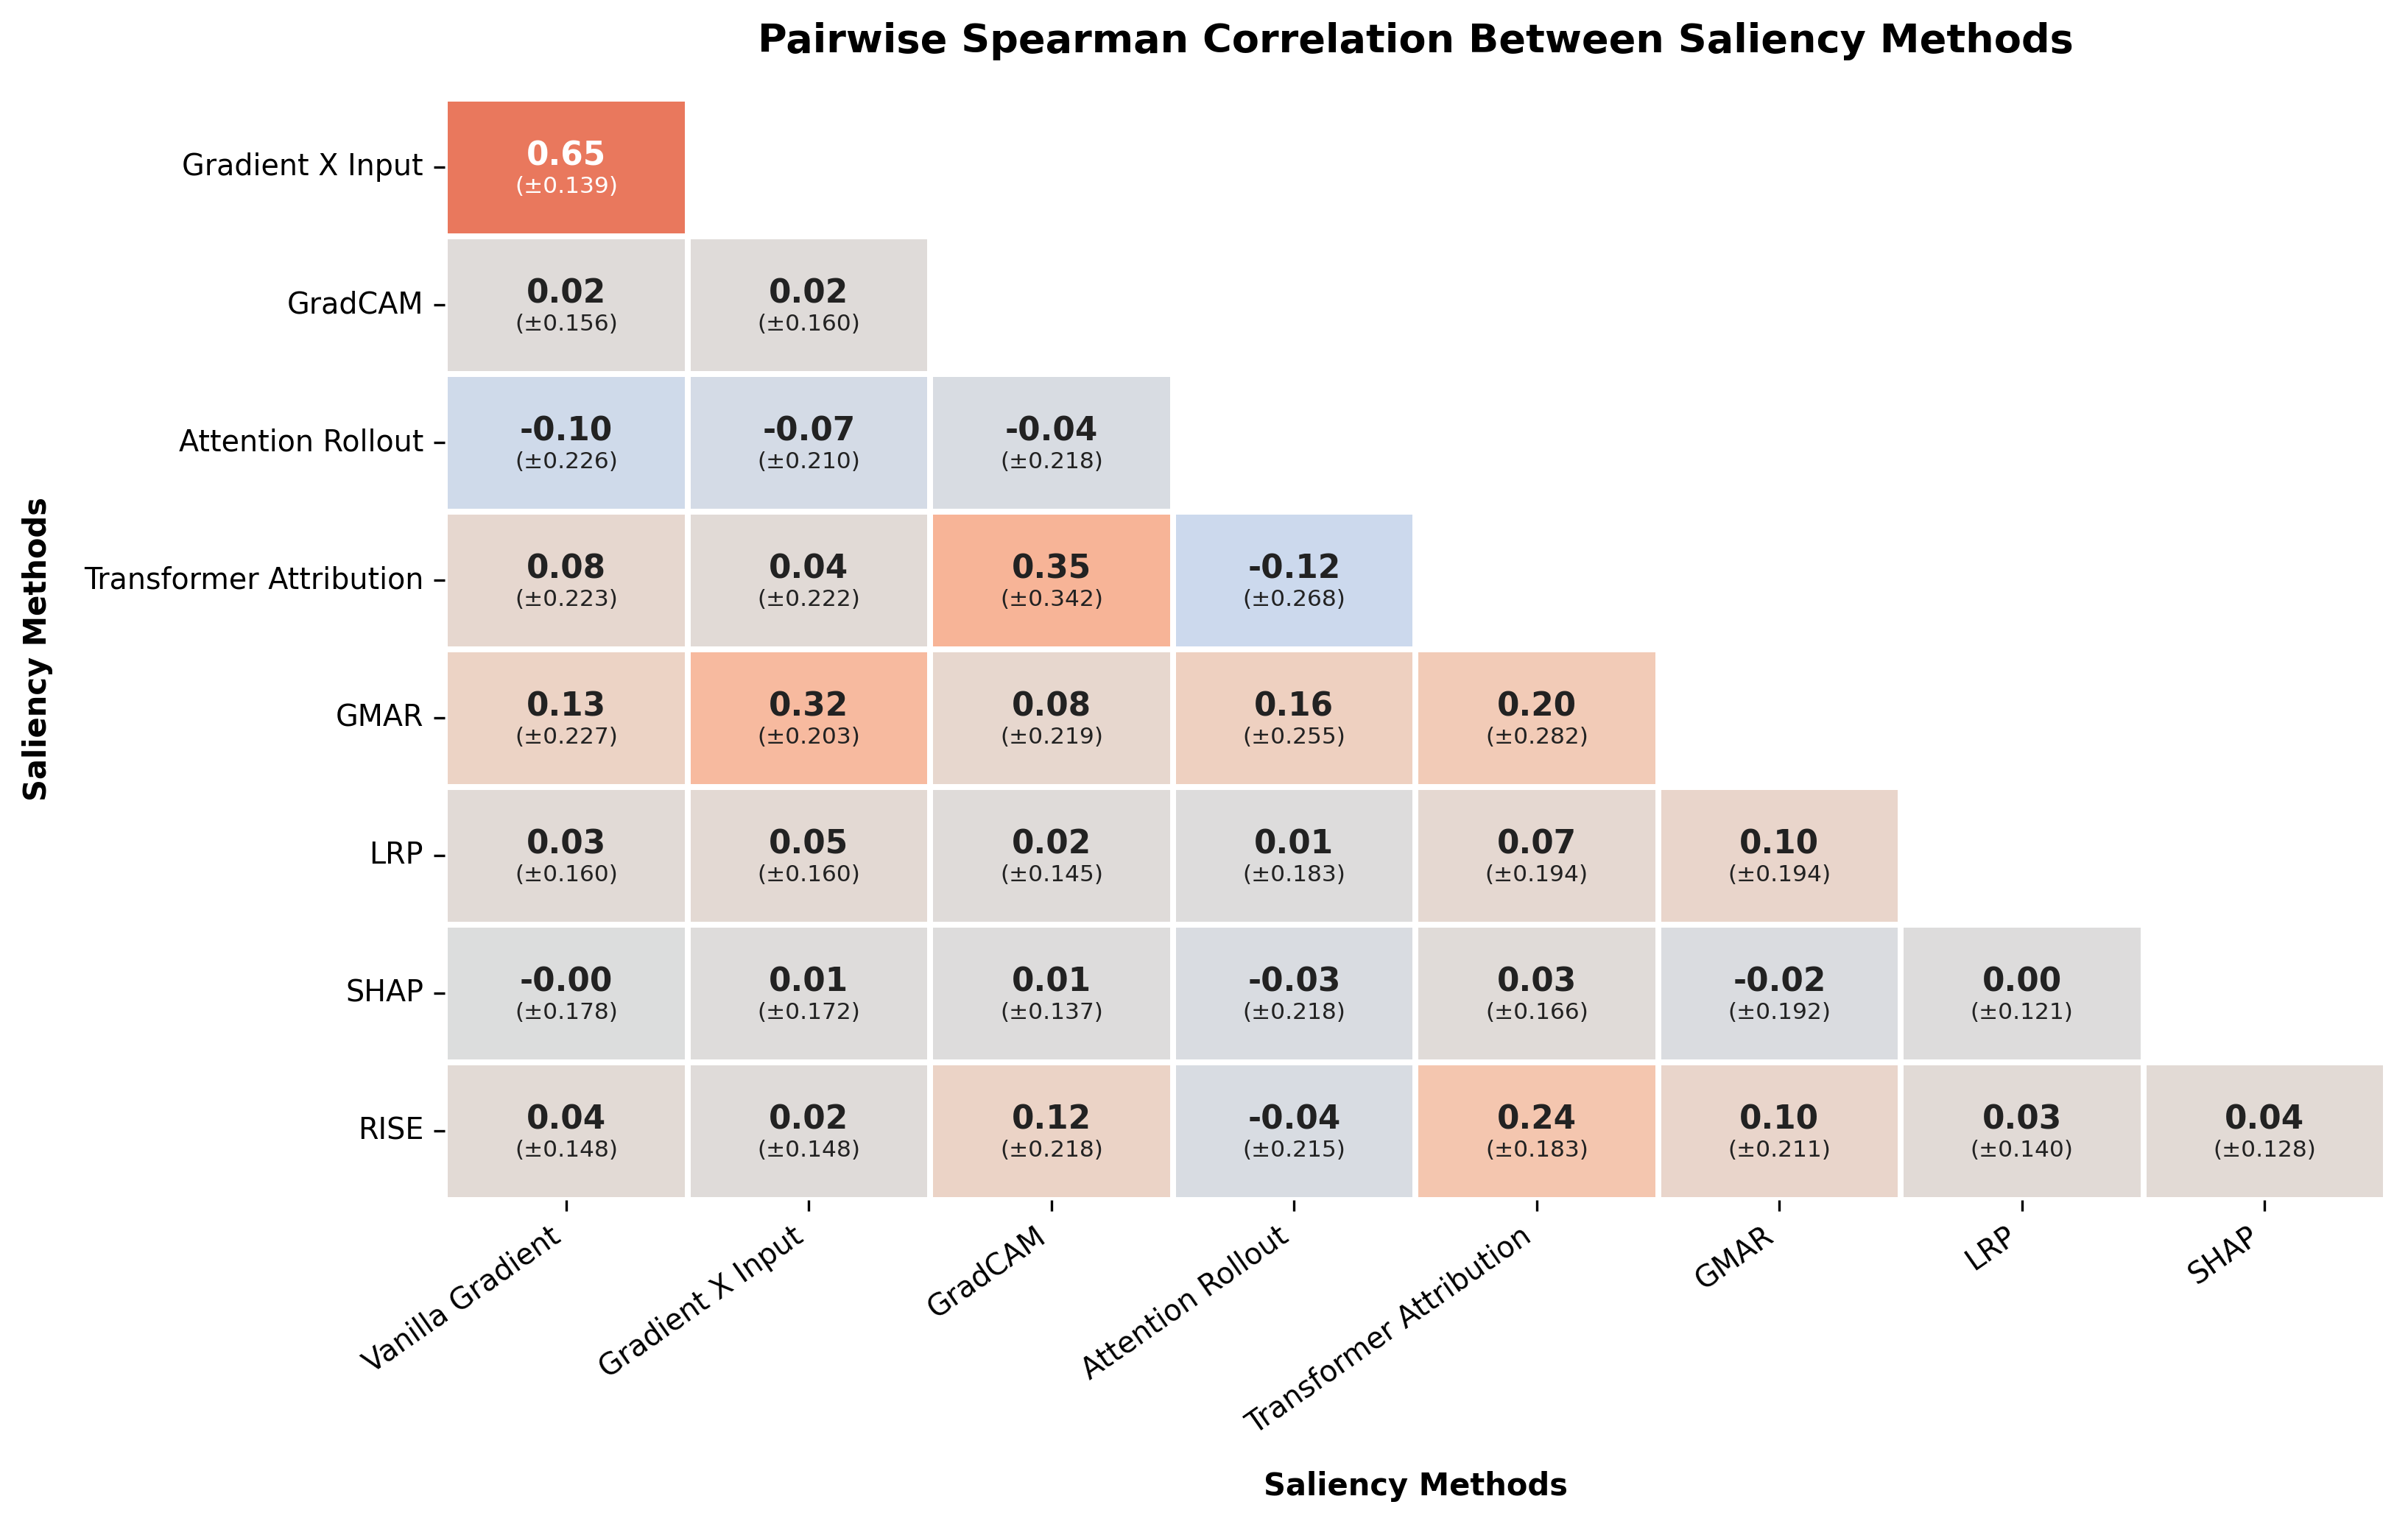

In [9]:
methods = list(saliencies.keys())
num_methods = len(methods)

mean_corr = np.zeros((num_methods, num_methods))
std_corr = np.zeros((num_methods, num_methods))

flattened_maps = {}
for m in methods:
    maps = saliencies[m]
    if isinstance(maps, torch.Tensor):
        maps = maps.detach().cpu().numpy()
    flattened_maps[m] = maps.reshape(maps.shape[0], -1)

for i, m1 in enumerate(methods):
    for j, m2 in enumerate(methods):
        if i > j:
            mean_corr[i, j] = mean_corr[j, i]
            std_corr[i, j] = std_corr[j, i]
            continue
            
        if i == j:
            mean_corr[i, j] = 1.0
            std_corr[i, j] = 0.0
            continue

        n_samples = min(flattened_maps[m1].shape[0], flattened_maps[m2].shape[0])
        valid_corrs = []
        
        for k in range(n_samples):
            map1 = flattened_maps[m1][k]
            map2 = flattened_maps[m2][k]

            if np.ptp(map1) <= 1e-6 or np.ptp(map2) <= 1e-6:
                continue
            
            try:
                corr, _ = spearmanr(map1, map2)
                if not np.isnan(corr):
                    valid_corrs.append(corr)
            except Exception:
                continue
            
        mean_corr[i, j] = np.mean(valid_corrs)
        std_corr[i, j] = np.std(valid_corrs)

mean_corr_trimmed = mean_corr[1:, :-1]
std_corr_trimmed = std_corr[1:, :-1]

yticklabels_trimmed = methods[1:]
xticklabels_trimmed = methods[:-1]

fig, ax = plt.subplots(figsize=(11, 7), dpi=300)

mask = np.zeros_like(mean_corr_trimmed, dtype=bool)
nrows, ncols = mean_corr_trimmed.shape
for i in range(nrows):
    for j in range(ncols):
        if (i + 1) <= j:
            mask[i, j] = True

cmap = sns.color_palette("coolwarm", as_cmap=True)
sns.heatmap(
    mean_corr_trimmed, 
    annot=False, 
    cmap=cmap, 
    vmin=-1, 
    vmax=1,
    mask=mask,
    xticklabels=xticklabels_trimmed, 
    yticklabels=yticklabels_trimmed, 
    ax=ax,
    cbar=False,
    linewidths=1.5,         
    linecolor='white'    
)

for i in range(nrows):
    for j in range(ncols):
        if not mask[i, j]:
            val_mean = mean_corr_trimmed[i, j]
            val_std = std_corr_trimmed[i, j]
            
            text_color = 'white' if abs(val_mean) > 0.6 else '#222222'
            
            ax.text(j + 0.5, i + 0.42, f"{val_mean:.2f}", 
                    ha='center', va='center', fontsize=10.5, fontweight='bold', color=text_color)
            ax.text(j + 0.5, i + 0.64, f"(±{val_std:.3f})", 
                    ha='center', va='center', fontsize=7.5, fontweight='normal', color=text_color)

ax.set_title("Pairwise Spearman Correlation Between Saliency Methods", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Saliency Methods", fontsize=10, fontweight='semibold', labelpad=10)
ax.set_ylabel("Saliency Methods", fontsize=10, fontweight='semibold', labelpad=10)

ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9.5)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9.5)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig("results/spearman_correlation.png", dpi=100)
plt.show()

## Robustness & Sanity Checks (Patch Perturbations)

In [ ]:
print(f"{'METHOD':<24} | {'SHUFFLE (Rho)':<16} | {'MOST SALIENT':<16} | {'LEAST SALIENT':<16} | {'RANDOM':<16}")
print("-" * 95)

for key in saliencies.keys():
    data = results.get(key, {})
    if not data:
        continue

    shuffle = data.get('patch_shuffle', {})
    most = data.get('patch_perturb_most_salient', {})
    least = data.get('patch_perturb_least_salient', {})
    rand = data.get('patch_perturb_random', {})

    def fmt(d):
        return f"{d.get('mean_rho', 0):.3f} ± {d.get('std_rho', 0):.3f}"

    print(f"{key:<24} | {fmt(shuffle):<16} | {fmt(most):<16} | {fmt(least):<16} | {fmt(rand):<16}")

METHOD                   | SHUFFLE (Rho)    | MOST SALIENT     | LEAST SALIENT    | RANDOM          
-----------------------------------------------------------------------------------------------
Vanilla Gradient         | 0.226 ± 0.223    | 0.876 ± 0.157    | 0.901 ± 0.152    | 0.898 ± 0.172   
Gradient X Input         | 0.412 ± 0.173    | 0.909 ± 0.107    | 0.940 ± 0.107    | 0.935 ± 0.112   
GradCAM                  | 0.047 ± 0.197    | 0.871 ± 0.213    | 0.930 ± 0.113    | 0.946 ± 0.095   
Attention Rollout        | 0.367 ± 0.154    | 0.982 ± 0.027    | 0.988 ± 0.020    | 0.988 ± 0.020   
Transformer Attribution  | 0.298 ± 0.184    | 0.908 ± 0.084    | 0.909 ± 0.080    | 0.911 ± 0.079   
GMAR                     | 0.727 ± 0.108    | 0.987 ± 0.011    | 0.996 ± 0.005    | 0.995 ± 0.006   
LRP                      | 0.025 ± 0.109    | 0.031 ± 0.133    | 0.045 ± 0.133    | 0.034 ± 0.131   
SHAP                     | 0.565 ± 0.107    | 0.893 ± 0.071    | 0.896 ± 0.075    | 0.900 ± 0.07

## Computational Efficiency & Latency Benchmark

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device).eval()
model_base = model_base.to(device).eval()

xai_instances = {
    "Vanilla Gradient":     xai_classes["VanillaGradient"](model),
    "Gradient x Input":     xai_classes["GradientXInput"](model),
    "Grad-CAM":             xai_classes["GradCAM"](model),
    "LRP":                  xai_classes["LRP"](model),
    "Attention Rollout":    xai_classes["AttentionRollout"](model),
    "Transformer Attrib.":  xai_classes["TransformerAttribution"](model),
    "GMAR":                 xai_classes["GMAR"](model),
    "KernelSHAP":           xai_classes["KernelSHAP"](model, model_base, n_masks=8000, batch_size=128),
    "RISE":                 xai_classes["RISE"](model, model_base, n_masks=6000, batch_size=256),
}

execution_times = {name: [] for name in xai_instances.keys()}

total_samples = len(dataloader)

for sample_idx, (img_tensor, label, *rest) in enumerate(dataloader, 1):
    img_tensor = img_tensor.to(device)
    label = label.to(device) if isinstance(label, torch.Tensor) else label

    for name, xai in xai_instances.items():
        if device.type == 'cuda':
            torch.cuda.synchronize()
        start_time = time.perf_counter()

        _ = xai.attribute(img_tensor, label)

        if device.type == 'cuda':
            torch.cuda.synchronize()
        end_time = time.perf_counter()

        elapsed_ms = (end_time - start_time) * 1000.0
        execution_times[name].append(elapsed_ms)

time_summary = []
for name, times in execution_times.items():
    time_summary.append({
        "Method": name,
        "Mean Time (ms)": np.mean(times),
        "Std Time (ms)": np.std(times),
        "FPS (Img/sec)": 1000.0 / np.mean(times)
    })

df_time = pd.DataFrame(time_summary).sort_values(by="Mean Time (ms)")

print(f"{'METHOD':<24} | {'MEAN TIME (ms)':<16} | {'STD (ms)':<12} | {'THROUGHPUT (FPS)':<16}")
print("-" * 75)
for _, row in df_time.iterrows():
    print(f"{row['Method']:<24} | {row['Mean Time (ms)']:<16.2f} | {row['Std Time (ms)']:<12.2f} | {row['FPS (Img/sec)']:<16.2f}")

METHOD                     | MEAN TIME (ms)   | STD (ms)     | THROUGHPUT (FPS)
--------------------------------------------------------------------------------
Attention Rollout          | 18.36            | 2.62         | 54.4662         
GradCAM                    | 30.18            | 4.69         | 33.1345         
Vanilla Gradient           | 44.69            | 5.03         | 22.3764         
Gradient x Input           | 45.81            | 6.82         | 21.8293         
GMAR                       | 48.62            | 4.31         | 20.5677         
LRP                        | 180.57           | 14.51        | 5.5380          
Transformer Attrib.        | 212.27           | 16.35        | 4.7110          
RISE                       | 38620.00         | 520.00       | 0.0259          
Kernel SHAP                | 52580.00         | 1220.00      | 0.0190          
